# Analisi statistica

In [4]:
# importo le librerie utili
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# importo il file csv
df = pd.read_csv('df_finale.csv',sep=';',keep_default_na=False)

In [6]:
# inizio a vedere le principali metriche per farmi un'idea sui dati che ho
df.describe().round(2)

,Codice comune,Anno,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
count,190900.00,190900.00,190900.00,190900.00,190900.00,190900.00,190900.0
mean,44492.22,2012.34,37.70,7423.75,35.10,0.53,25.0
std,32071.71,6.86,50.40,41024.15,338.34,2.79,257.7
min,1001.00,2001.00,0.12,28.00,0.00,0.00,0.0
25%,16137.00,2006.00,11.33,1032.00,1.00,0.00,1.0
50%,38009.00,2012.00,22.13,2442.00,5.00,0.00,3.0
75%,71048.00,2018.00,43.81,6115.25,18.00,0.00,12.0
max,111107.00,2024.00,1288.19,2820219.00,30254.00,363.00,23135.0


## EDA
Ho deciso di analizzare nello specifico le metriche legate agli incidenti perchè sono quelle che mi aiuteranno a rispondere alle richieste del compito (dove investire per la sicurezza stradale).
i restanti dati legati ai comuni, superficie anno e popolazione residente li userò a supporto dei valori che andrò ad usare/presentare 

### analisi dei valori max 

quelli che a un primo momento mi potevano sembrare degli outlier ( i max), per via della differenza tra valore max e le altre metriche, alla fine ho riscontrato che tutti questi valori sono legati a Roma.
Essendo Roma la città con la popolazione più densa ha senso che questi valori siano concentrati su questo Comune in particolare.

In [ ]:
# verifico con un filtro a cosa fa riferimenento il volore più alto dei feriti
df[df['Feriti'] == df['Feriti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116081,58091,Roma,2004,Annuale,1287.3371,2566690,30254,260,23135


In [ ]:
# verifico con un filtro a cosa fa riferimenento il volore più alto degli incidenti

df[df['Incidenti'] == df['Incidenti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116081,58091,Roma,2004,Annuale,1287.3371,2566690,30254,260,23135


In [ ]:
# verifico con un filtro a cosa fa riferimenento il volore più alto degli abitanti/residenti
df[df['Popolazione residente'] == df['Popolazione residente'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116095,58091,Roma,2018,Annuale,1287.3895,2820219,15551,148,11995


In [ ]:
# verifico con un filtro a cosa fa riferimenento il volore più alto dei morti
df[df['Morti'] == df['Morti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116079,58091,Roma,2002,Annuale,1287.3371,2544815,26696,363,21330


### analisi della distruibuzione dati
Ho deciso di analizzare i dati inerenti agli incidenti con il boxplot e istogrammi perchè la differenza tra la media e mediana (nel .describe()) mi suggerisce la presenza di outliers che trascinano la media verso valori più alti indicando quindi una distribuzione dei valori non lineare (skewness positiva) perchè appunto abbiamo valori (bassi) legati a piccoli comuni (che sono la maggioranza) e valori (alti) legati a grandi comuni (che sono la minoranza).

### Boxplot

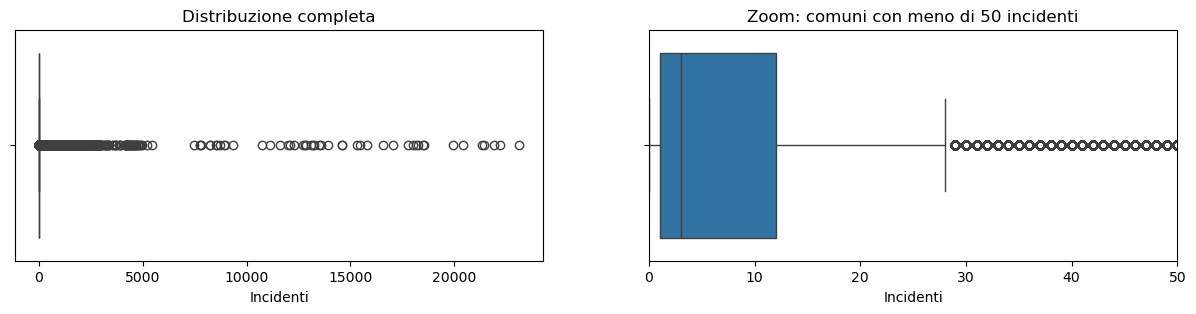

Q1: 1.0
Q2 (Mediana): 3.0
Q3: 12.0
Range interquartile: 11.0
il valore massimo accettato prima di essere considerato un outlier è:28.5


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

sns.boxplot(x=df['Incidenti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Incidenti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 incidenti')

plt.show()

print(f'Q1: {df['Incidenti'].quantile(0.25)}')
print(f'Q2 (Mediana): {df['Incidenti'].quantile(0.50)}')
print(f'Q3: {df['Incidenti'].quantile(0.75)}')
print(f'Range interquartile: {df['Incidenti'].quantile(0.75) - df['Incidenti'].quantile(0.25)}')
print(f'il valore massimo accettato prima di essere considerato un outlier è:{df['Incidenti'].quantile(0.75) + 1.5 * (df['Incidenti'].quantile(0.75) - df['Incidenti'].quantile(0.25))}')


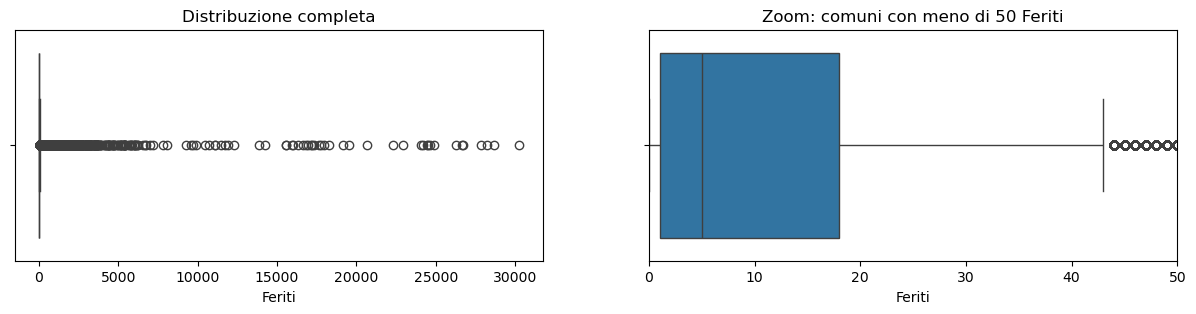

Q1: 1.0
Q2 (Mediana): 5.0
Q3: 18.0
Range interquartile: 17.0
il valore massimo accettato prima di essere considerato un outlier è:43.5


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

sns.boxplot(x=df['Feriti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Feriti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 Feriti')

plt.show()

print(f'Q1: {df['Feriti'].quantile(0.25)}')
print(f'Q2 (Mediana): {df['Feriti'].quantile(0.50)}')
print(f'Q3: {df['Feriti'].quantile(0.75)}')
print(f'Range interquartile: {df['Feriti'].quantile(0.75) - df['Feriti'].quantile(0.25)}')
print(f'il valore massimo accettato prima di essere considerato un outlier è:{df['Feriti'].quantile(0.75) + 1.5 * (df['Feriti'].quantile(0.75) - df['Feriti'].quantile(0.25))}')

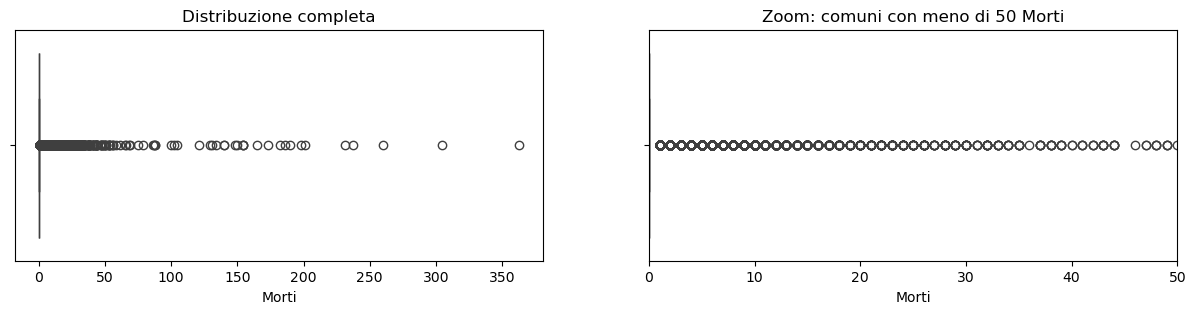

Q1: 0.0
Q2 (Mediana): 0.0
Q3: 0.0
Range interquartile: 0.0
il valore massimo accettato prima di essere considerato un outlier è:0.0
vuol dire che qualsiasi valore sopra a 0 è outlier


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

sns.boxplot(x=df['Morti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Morti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 Morti')

plt.show()

print(f'Q1: {df['Morti'].quantile(0.25)}')
print(f'Q2 (Mediana): {df['Morti'].quantile(0.50)}')
print(f'Q3: {df['Morti'].quantile(0.75)}')
print(f'Range interquartile: {df['Morti'].quantile(0.75) - df['Morti'].quantile(0.25)}')
print(f'il valore massimo accettato prima di essere considerato un outlier è:{df['Morti'].quantile(0.75) + 1.5 * (df['Morti'].quantile(0.75) - df['Morti'].quantile(0.25))}')
print(f'vuol dire che qualsiasi valore sopra a 0 è outlier')

In [114]:
# ora grazie a queste analisi volendo posso risalire a dei dati specifici, come ad esempio risalire a tutti i comuni con un numero di incidenti statisticamente elevato:
df[df['Incidenti'] >= 28.5].sort_values('Incidenti',ascending=False).head(5)

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116081,58091,Roma,2004,Annuale,1287.3371,2566690,30254,260,23135
116078,58091,Roma,2001,Annuale,1287.3372,2545977,27865,305,22220
116082,58091,Roma,2005,Annuale,1287.3371,2565386,28653,237,21902
116083,58091,Roma,2006,Annuale,1287.3371,2586029,28209,231,21452
116079,58091,Roma,2002,Annuale,1287.3371,2544815,26696,363,21330


### Istogramma 

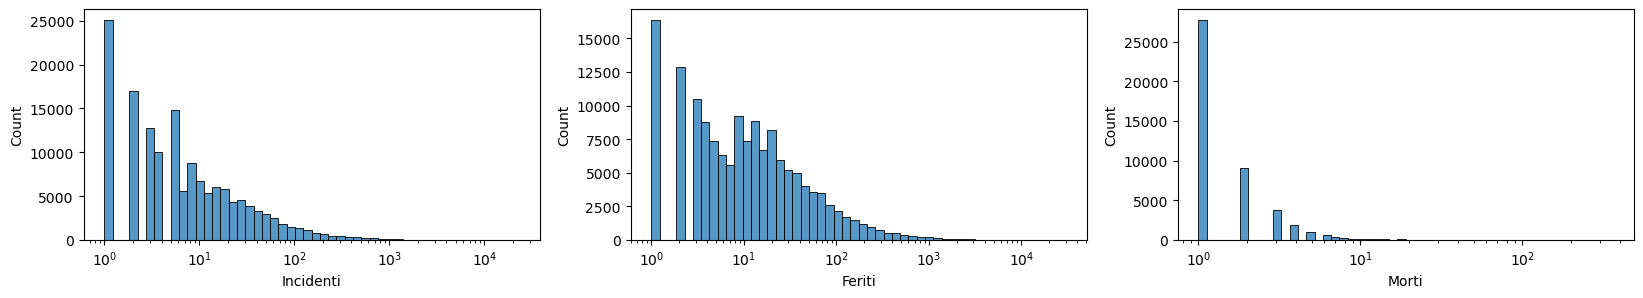

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(20, 3))

sns.histplot(x='Incidenti', data=df, bins=50, ax=axes[0],log_scale=True)
sns.histplot(x='Feriti', data=df, bins=50, ax=axes[1],log_scale=True)
sns.histplot(x='Morti', data=df, bins=50, ax=axes[2],log_scale=True)
plt.show()

In [ ]:
print(f'Incidenti: ha una skewed positiva, i valori sono più accorpati a sinitra quindi la maggior parte dei comuni non ha molti incidenti all anno. dove non ci sono colonne è perchè non ci sono dati/valori dentro a quel specifico range di incidenti')
print(f'Feriti: ha una skewed positiva, in questo caso i valori sono distribuiti più verso destra. questo mi fa capire che, per logica, un incidente può causare più di un ferito e per questo vedo valori più alti')
print(f'Morti: ha una skewed positiva, più marcata rispetto agli altri dati ma perchè i pochi valori che abbiamo si concentrano su un valore basso. i vuoti sono dovuti al fatto che sono eventi più rari e concentrati, quindi molti range non hanno dati.')
print(f'Conclusione: il numero di incidenti sembra attenuarsi su valori bassi per la maggior parte dei comuni ma questo non implica meno feriti... anzi vedo che quelli hanno distribuzione maggiore per i vari range mentre per i morti sembrerebbe essere un evento più raro ma non impossibile.')

Incidenti: ha una skewed positiva, i valori sono più accoprtati a sinitra quindi la maggior parte dei comuni non ha molti incidenti all anno. dove non ci sono colonne è perchè non ci sono dati/valori dentro a quel specifico range di incidenti
Feriti: ha una skewed positiva, in questo caso i valori sono distruibuiti più verso destra. questo mi fa capire che, per logica, un incidente può causare più di un ferito e per questo vedo valori più alti
Morti: ha una skewed positiva, più marcata rispetto agli altri dati ma perchè i pochi valori che abbiamo si concentrano su un valore basso. i vuoti sono dovuti al fatto che sono eventi più rari e concentrati, quindi molti range non hanno dati.
Conclusione: il numero di incidenti sembra attenuarsi su valori bassi per la maggior parte dei comuni ma questo non implica meno feriti... anzi vedo che quelli hanno distribuzione maggiore per i vari range mentre per i morti sembrerebbe essere un evento più raro ma non impossibile.


### Top 10 comuni per incidenti 

In [40]:
# tabella che raggrupa per comuni in ordine decrescente per incidenti
df.groupby('Comune')[['Incidenti','Feriti','Morti']].sum().sort_values('Incidenti', ascending=False).head(10)

,Incidenti,Feriti,Morti
Comune,,,
Roma,390605,506345,4350
Milano,272545,355984,1435
Genova,102694,128139,580
Torino,87227,129752,895
Firenze,74537,90339,425
Napoli,60731,83636,881
Palermo,54030,73910,716
Bologna,53858,70091,565
Bari,44172,66703,357


Ho provato a riordinare anche per feriti e morti.. non cambia molto la tabella, cambia solo di 1 / 2 comuni. quindi questi sarebbero una buona base di partenza su cui potersi focalizzare

### Trend degli incidenti

In [92]:
# raggruppo tutto per anno e calcolo la somma degli incidenti
df_trend = df.groupby('Anno')[['Incidenti','Morti','Feriti']].sum()
#print(df_trand.shape) per verificare che ci siano 24 righe
df_trend

,Incidenti,Morti,Feriti
Anno,,,
2001,263100,7096,373286
2002,265402,6980,378491
2003,252261,6561,356463
2004,243490,6122,343179
2005,240011,5818,334858
2006,238124,5669,332955
2007,230871,5131,325850
2008,218963,4725,310745
2009,210256,4149,299734


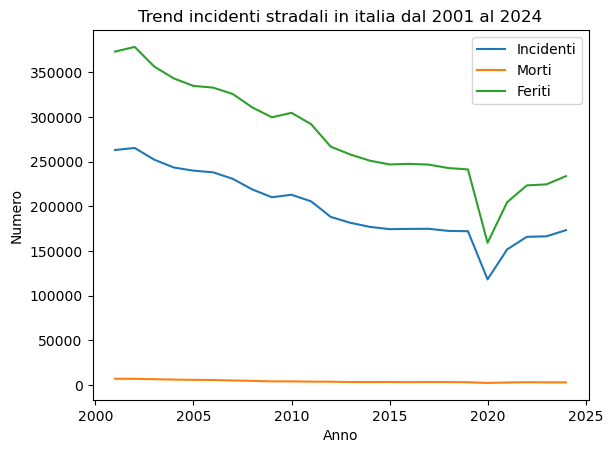

In [ ]:
df_trend.plot()
plt.title('Trend incidenti stradali in italia dal 2001 al 2024')
plt.xlabel('Anno')
plt.ylabel('Numero')
plt.show()

print(f'')